# Analisis Likert de satisfaccion de Power App

Este notebook implementa un flujo de analisis consolidado para encuestas tipo Likert (1 a 5), con:

- Carga de datos desde SharePoint/OneDrive o respaldo local.
- Limpieza y estandarizacion de respuestas.
- Frecuencias, sumatoria, promedio, desviacion y favorabilidad.
- Ranking de preguntas (peor a mejor).
- Indice global de satisfaccion y alfa de Cronbach.
- Exportacion de resultados.

## 1. Set Up Notebook Environment

Importa librerias, ajusta configuracion de visualizacion y valida disponibilidad de paquetes opcionales.

In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import io
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)


pandas: 3.0.2
numpy: 2.4.4


## 2. Define Configuration and Constants

Configura rutas, fuente de datos y parametros de la escala Likert.

In [6]:
BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW_DIR = BASE_DIR / "data" / "raw"
DATA_PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

for p in [DATA_RAW_DIR, DATA_PROCESSED_DIR, OUTPUTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "use_sharepoint": False,
    "local_fallback_file": DATA_RAW_DIR / "Experiencia_en_el_uso_de_Power_App_B-Lab.xlsx",
    "sheet_name": 0,
    "id_column": "Id",
    "open_text_columns": [
        "Si pudieras cambiar solo una cosa para mejorar la Power App, ¿Cuál sería?",
        "En tu día a día, ¿Qué te impediría hacer uso de la PowerApp?",
    ],
    "metadata_columns": [
        "Id",
        "Hora de inicio",
        "Hora de finalización",
        "Correo electrónico",
        "Nombre",
    ],
}

LIKERT_MAP = {
    "totalmente en desacuerdo": 1,
    "en desacuerdo": 2,
    "ni de acuerdo ni en desacuerdo": 3,
    "de acuerdo": 4,
    "totalmente de acuerdo": 5,
}

print("BASE_DIR:", BASE_DIR)
print("Archivo local:", CONFIG["local_fallback_file"])
print("Archivo existe:", Path(CONFIG["local_fallback_file"]).exists())


BASE_DIR: C:\Users\David\Documents\Maestría en Estudios del Comportamiento\tablero_pre_pos_intervencion
Archivo local: C:\Users\David\Documents\Maestría en Estudios del Comportamiento\tablero_pre_pos_intervencion\data\raw\Experiencia_en_el_uso_de_Power_App_B-Lab.xlsx
Archivo existe: True


In [7]:
local_exists = Path(CONFIG["local_fallback_file"]).exists()

print("Diagnostico de carga (modo local)")
print("- Archivo:", CONFIG["local_fallback_file"])
print("- Existe:", local_exists)

if not local_exists:
    print("\nAccion requerida: copia el xlsx en data/raw con el nombre:")
    print(f"  {Path(CONFIG['local_fallback_file']).name}")
else:
    print("\nListo para cargar datos localmente.")


Diagnostico de carga (modo local)
- Archivo: C:\Users\David\Documents\Maestría en Estudios del Comportamiento\tablero_pre_pos_intervencion\data\raw\Experiencia_en_el_uso_de_Power_App_B-Lab.xlsx
- Existe: True

Listo para cargar datos localmente.


## 3. Implement Core Functions

Funciones para ingesta, normalizacion, transformacion Likert y metricas.

In [8]:
def normalize_text(value: object) -> str:
    """Normaliza texto para comparaciones robustas: lower, sin acentos, espacios limpios."""
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"\s+", " ", text)
    return text


def download_excel_from_sharepoint(config: dict) -> io.BytesIO:
    """Descarga archivo desde SharePoint usando credenciales de entorno."""
    if not HAS_O365:
        raise RuntimeError(
            "No se encontro office365-rest-python-client. Instala dependencias y reintenta."
        )

    required = [
        config["sharepoint_site_url"],
        config["sharepoint_file_server_relative_url"],
        config["sharepoint_username"],
        config["sharepoint_password"],
    ]
    if not all(required):
        raise ValueError(
            "Faltan variables de entorno SP_SITE_URL, SP_FILE_SERVER_RELATIVE_URL, SP_USERNAME o SP_PASSWORD."
        )

    ctx = ClientContext(config["sharepoint_site_url"]).with_credentials(
        UserCredential(config["sharepoint_username"], config["sharepoint_password"])
    )
    file_stream = io.BytesIO()
    sp_file = ctx.web.get_file_by_server_relative_url(config["sharepoint_file_server_relative_url"])
    sp_file.download(file_stream).execute_query()
    file_stream.seek(0)
    return file_stream


def load_survey_dataframe(config: dict) -> pd.DataFrame:
    """Carga dataframe desde SharePoint o fallback local."""
    if config["use_sharepoint"]:
        try:
            excel_bytes = download_excel_from_sharepoint(config)
            print("Lectura remota OK desde SharePoint/OneDrive")
            return pd.read_excel(excel_bytes, sheet_name=config["sheet_name"])
        except Exception as exc:
            error_text = str(exc)
            print(f"No fue posible leer remoto: {error_text}")
            if "AADSTS53003" in error_text:
                print("Diagnostico: el acceso remoto esta bloqueado por politicas de Conditional Access.")
                print("Accion: descarga el Excel manualmente y guardalo en data/raw con el nombre esperado.")
            print("Intentando archivo local fallback...")

    fallback = Path(config["local_fallback_file"])
    if not fallback.exists():
        raise FileNotFoundError(
            f"No se encontro archivo fallback en {fallback}. Descargalo manualmente o configura SharePoint."
        )
    return pd.read_excel(fallback, sheet_name=config["sheet_name"])


def detect_likert_columns(df: pd.DataFrame, config: dict) -> list[str]:
    """Identifica columnas Likert excluyendo metadata y abiertas."""
    excluded = set(config["metadata_columns"] + config["open_text_columns"])
    return [c for c in df.columns if c not in excluded]


def map_likert_series(series: pd.Series) -> pd.Series:
    """Mapea respuestas en texto a escala Likert numerica 1-5."""
    normalized = series.map(normalize_text)

    synonyms = {
        "totalmente en desacuerdo": "totalmente en desacuerdo",
        "en desacuerdo": "en desacuerdo",
        "ni de acuerdo ni en desacuerdo": "ni de acuerdo ni en desacuerdo",
        "neutral": "ni de acuerdo ni en desacuerdo",
        "de acuerdo": "de acuerdo",
        "totalmente de acuerdo": "totalmente de acuerdo",
    }

    canonical = normalized.map(lambda x: synonyms.get(x, x))
    return canonical.map(LIKERT_MAP)


def cronbach_alpha(df_numeric: pd.DataFrame) -> float:
    """Calcula alfa de Cronbach para consistencia interna."""
    clean = df_numeric.dropna(axis=0, how="any")
    if clean.shape[0] < 2 or clean.shape[1] < 2:
        return np.nan

    item_variances = clean.var(axis=0, ddof=1)
    total_scores = clean.sum(axis=1)
    total_variance = total_scores.var(ddof=1)
    k = clean.shape[1]

    if total_variance == 0:
        return np.nan

    alpha = (k / (k - 1)) * (1 - (item_variances.sum() / total_variance))
    return float(alpha)


def compute_question_metrics(df_likert_num: pd.DataFrame) -> pd.DataFrame:
    """Calcula metricas principales por pregunta para ranking y reporte."""
    metrics = pd.DataFrame({
        "pregunta": df_likert_num.columns,
        "n_validas": df_likert_num.notna().sum().values,
        "sumatoria": df_likert_num.sum(skipna=True).values,
        "promedio": df_likert_num.mean(skipna=True).values,
        "desviacion": df_likert_num.std(skipna=True, ddof=1).values,
        "favorabilidad_pct": (df_likert_num.isin([4, 5]).sum() / df_likert_num.notna().sum() * 100).values,
    })
    return metrics.sort_values(["promedio", "favorabilidad_pct"], ascending=[True, True]).reset_index(drop=True)


def compute_frequencies(df_likert_num: pd.DataFrame) -> pd.DataFrame:
    """Frecuencias absolutas por categoria 1-5 para cada pregunta."""
    freq = []
    for col in df_likert_num.columns:
        counts = df_likert_num[col].value_counts(dropna=True).reindex([1, 2, 3, 4, 5], fill_value=0)
        freq.append({
            "pregunta": col,
            "1_totalmente_en_desacuerdo": int(counts.loc[1]),
            "2_en_desacuerdo": int(counts.loc[2]),
            "3_neutral": int(counts.loc[3]),
            "4_de_acuerdo": int(counts.loc[4]),
            "5_totalmente_de_acuerdo": int(counts.loc[5]),
        })
    return pd.DataFrame(freq)

### Funciones adicionales: ranking extendido y preguntas abiertas

Estas funciones agregan top box, desfavorabilidad y neto de favorabilidad, ademas de un resumen de texto abierto por frecuencia de terminos.

In [9]:
def compute_question_metrics_enhanced(df_likert_num: pd.DataFrame) -> pd.DataFrame:
    """Metricas extendidas por pregunta para priorizacion mas precisa."""
    n_valid = df_likert_num.notna().sum()
    favorable = (df_likert_num.isin([4, 5]).sum() / n_valid) * 100
    top_box = ((df_likert_num == 5).sum() / n_valid) * 100
    unfavorable = (df_likert_num.isin([1, 2]).sum() / n_valid) * 100

    metrics = pd.DataFrame({
        "pregunta": df_likert_num.columns,
        "n_validas": n_valid.values,
        "sumatoria": df_likert_num.sum(skipna=True).values,
        "promedio": df_likert_num.mean(skipna=True).values,
        "desviacion": df_likert_num.std(skipna=True, ddof=1).values,
        "favorabilidad_pct": favorable.values,
        "top_box_pct": top_box.values,
        "desfavorabilidad_pct": unfavorable.values,
        "neto_favorabilidad_pct": (favorable - unfavorable).values,
    })

    # Prioriza peor a mejor por promedio; en empate usa neto y top-box
    return metrics.sort_values(
        ["promedio", "neto_favorabilidad_pct", "top_box_pct"],
        ascending=[True, True, True],
    ).reset_index(drop=True)


def analyze_open_questions(df_raw: pd.DataFrame, open_text_columns: list[str], top_n: int = 12):
    """Resume preguntas abiertas: cantidad de respuestas y terminos frecuentes."""
    from collections import Counter

    stopwords = {
        "que", "para", "con", "una", "las", "los", "del", "por", "muy", "mas", "pero",
        "esta", "este", "esto", "ser", "son", "fue", "han", "hay", "como", "sin", "uso",
        "app", "power", "nada", "todo", "bien", "solo", "sobre", "desde", "entre", "puede",
    }

    summary_records = []
    terms_records = []

    for col in open_text_columns:
        if col not in df_raw.columns:
            continue

        s = df_raw[col].dropna().astype(str).str.strip()
        s = s[s != ""]
        n_resp = int(s.shape[0])

        summary_records.append({
            "pregunta_abierta": col,
            "n_respuestas_no_vacias": n_resp,
            "longitud_promedio_texto": float(s.str.len().mean()) if n_resp > 0 else 0.0,
        })

        if n_resp == 0:
            continue

        tokens = []
        for text in s:
            clean = normalize_text(text)
            for tok in re.findall(r"[a-zA-Z]{3,}", clean):
                if tok not in stopwords:
                    tokens.append(tok)

        for term, count in Counter(tokens).most_common(top_n):
            terms_records.append({
                "pregunta_abierta": col,
                "termino": term,
                "frecuencia": int(count),
            })

    summary_df = pd.DataFrame(summary_records)
    terms_df = pd.DataFrame(terms_records)
    return summary_df, terms_df

## 4. Create a Minimal Executable Pipeline

Ejecuta el flujo de carga, transformacion, ranking y exportacion en un unico bloque.

In [12]:
df_raw = load_survey_dataframe(CONFIG)
print("Filas/columnas:", df_raw.shape)

likert_columns = detect_likert_columns(df_raw, CONFIG)
print("Preguntas Likert detectadas:", len(likert_columns))

if len(likert_columns) == 0:
    raise ValueError("No se detectaron columnas Likert. Revisa metadata_columns/open_text_columns en CONFIG.")

df_likert_text = df_raw[likert_columns].copy()
df_likert_num = df_likert_text.apply(map_likert_series)

freq_df = compute_frequencies(df_likert_num)
metrics_df = compute_question_metrics_enhanced(df_likert_num)

worst_question = metrics_df.iloc[0]["pregunta"]
worst_score = metrics_df.iloc[0]["promedio"]

global_index = float(df_likert_num.stack().mean())
alpha = cronbach_alpha(df_likert_num)

# Analisis de preguntas abiertas
open_summary_df, open_terms_df = analyze_open_questions(df_raw, CONFIG["open_text_columns"], top_n=12)

print(f"Pregunta peor calificada: {worst_question}")
print(f"Promedio de la peor pregunta: {worst_score:.2f}")
print(f"Indice global de satisfaccion (1-5): {global_index:.2f}")
print(f"Alfa de Cronbach: {alpha:.3f}" if pd.notna(alpha) else "Alfa de Cronbach no calculable")

metrics_export = metrics_df.copy()
freq_export = freq_df.copy()

metrics_export.to_csv(OUTPUTS_DIR / "ranking_preguntas.csv", index=False, encoding="utf-8-sig")
freq_export.to_csv(OUTPUTS_DIR / "resumen_metricas.csv", index=False, encoding="utf-8-sig")
open_summary_df.to_csv(OUTPUTS_DIR / "preguntas_abiertas_resumen.csv", index=False, encoding="utf-8-sig")
open_terms_df.to_csv(OUTPUTS_DIR / "preguntas_abiertas_terminos.csv", index=False, encoding="utf-8-sig")

print("Archivos exportados:")
print(OUTPUTS_DIR / "ranking_preguntas.csv")
print(OUTPUTS_DIR / "resumen_metricas.csv")
print(OUTPUTS_DIR / "preguntas_abiertas_resumen.csv")
print(OUTPUTS_DIR / "preguntas_abiertas_terminos.csv")

print("\nTop 10 ranking (peor -> mejor):")
display(metrics_df.head(10))

print("\nResumen de preguntas abiertas:")
display(open_summary_df)

print("\nTerminos mas frecuentes en abiertas (top 20):")
display(open_terms_df.head(20))

Filas/columnas: (28, 18)
Preguntas Likert detectadas: 11
Pregunta peor calificada: Comparto con otras personas conocimientos encontrados en la herramienta .Selecciona
Promedio de la peor pregunta: 3.67
Indice global de satisfaccion (1-5): 3.94
Alfa de Cronbach: 0.997
Archivos exportados:
C:\Users\David\Documents\Maestría en Estudios del Comportamiento\tablero_pre_pos_intervencion\outputs\ranking_preguntas.csv
C:\Users\David\Documents\Maestría en Estudios del Comportamiento\tablero_pre_pos_intervencion\outputs\resumen_metricas.csv
C:\Users\David\Documents\Maestría en Estudios del Comportamiento\tablero_pre_pos_intervencion\outputs\preguntas_abiertas_resumen.csv
C:\Users\David\Documents\Maestría en Estudios del Comportamiento\tablero_pre_pos_intervencion\outputs\preguntas_abiertas_terminos.csv

Top 10 ranking (peor -> mejor):


,pregunta,n_validas,sumatoria,promedio,desviacion,favorabilidad_pct,top_box_pct,desfavorabilidad_pct,neto_favorabilidad_pct
0,Comparto con otras personas conocimientos enco...,24,88.0,3.666667,1.274044,79.166667,20.833333,20.833333,58.333333
1,Siento que la app puede ser mi herramienta pri...,24,91.0,3.791667,1.250362,79.166667,29.166667,20.833333,58.333333
2,Considero que esta App puede ser útil incluso ...,26,100.0,3.846154,1.405484,76.923077,42.307692,23.076923,53.846154
3,Las herramientas prácticas que te permiten dil...,24,95.0,3.958333,1.232853,83.333333,37.500000,16.666667,66.666667
4,Considero que la herramienta mejora/facilita l...,26,103.0,3.961538,1.280024,80.769231,42.307692,19.230769,61.538462
5,Entiendo el propósito de cada sección de la ap...,27,108.0,4.000000,1.176697,81.481481,40.740741,18.518519,62.962963
6,Sé cómo navegar la herramienta.Selecciona,25,100.0,4.000000,1.224745,84.000000,40.000000,16.000000,68.000000
7,Puedo asociar el contenido teórico de la Power...,25,100.0,4.000000,1.224745,84.000000,40.000000,16.000000,68.000000
8,Usar esta herramienta me motiva a aplicar Cien...,26,105.0,4.038462,1.310901,80.769231,50.000000,19.230769,61.538462
9,La usaría en futuras iniciativas. .Selecciona,26,105.0,4.038462,1.310901,80.769231,50.000000,19.230769,61.538462



Resumen de preguntas abiertas:


,pregunta_abierta,n_respuestas_no_vacias,longitud_promedio_texto
0,Si pudieras cambiar solo una cosa para mejorar...,17,131.941176
1,"En tu día a día, ¿Qué te impediría hacer uso d...",18,95.500000



Terminos mas frecuentes en abiertas (top 20):


,pregunta_abierta,termino,frecuencia
0,Si pudieras cambiar solo una cosa para mejorar...,herramienta,5
1,Si pudieras cambiar solo una cosa para mejorar...,experiencia,4
2,Si pudieras cambiar solo una cosa para mejorar...,falta,3
3,Si pudieras cambiar solo una cosa para mejorar...,veo,2
4,Si pudieras cambiar solo una cosa para mejorar...,intervenciones,2
5,Si pudieras cambiar solo una cosa para mejorar...,comportamientos,2
6,Si pudieras cambiar solo una cosa para mejorar...,cambiaria,2
7,Si pudieras cambiar solo una cosa para mejorar...,contenido,2
8,Si pudieras cambiar solo una cosa para mejorar...,guia,2
9,Si pudieras cambiar solo una cosa para mejorar...,diseno,2


## 5. Run Sanity Checks and Assertions

Validaciones de forma, mapeo y consistencia de frecuencias.

In [13]:
assert len(likert_columns) > 0, "Debe existir al menos una pregunta Likert"
assert set(metrics_df.columns) >= {"pregunta", "sumatoria", "promedio", "favorabilidad_pct"}, "Faltan columnas esperadas"

# Todos los valores mapeados deben estar entre 1 y 5 (o NaN)
valid_mask = df_likert_num.apply(lambda s: s.dropna().isin([1, 2, 3, 4, 5]).all())
assert bool(valid_mask.all()), "Se detectaron valores fuera de escala Likert 1-5"

# Consistencia: sumatoria de frecuencias == numero de respuestas validas por pregunta
freq_totals = freq_df[[
    "1_totalmente_en_desacuerdo",
    "2_en_desacuerdo",
    "3_neutral",
    "4_de_acuerdo",
    "5_totalmente_de_acuerdo",
]].sum(axis=1)
valid_totals = df_likert_num.notna().sum(axis=0).reset_index(drop=True)
assert (freq_totals.reset_index(drop=True) == valid_totals).all(), "Frecuencias no cuadran con respuestas validas"

print("Sanity checks OK")

Sanity checks OK


## 6. Add Basic Unit Tests

Pruebas rapidas para funciones criticas y casos borde.

In [14]:
# Test normalize_text
assert normalize_text("  TOTALMENTE de Acuerdo ") == "totalmente de acuerdo"
assert normalize_text("acción") == "accion"

# Test map_likert_series
test_series = pd.Series(["Totalmente en desacuerdo", "En desacuerdo", "Neutral", "De acuerdo", "Totalmente de acuerdo", None])
mapped = map_likert_series(test_series)
assert mapped.tolist()[:5] == [1, 2, 3, 4, 5]
assert pd.isna(mapped.iloc[5])

# Test cronbach_alpha minimo
alpha_test_df = pd.DataFrame({
    "p1": [1, 2, 3, 4],
    "p2": [1, 2, 3, 4],
    "p3": [2, 2, 3, 5],
})
assert pd.notna(cronbach_alpha(alpha_test_df))

print("Tests basicos OK")

Tests basicos OK


## 7. Execute and Inspect Outputs

Visualiza distribuciones Likert y ranking final.

C:\Users\David\AppData\Local\Temp\ipykernel_12036\3037981734.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


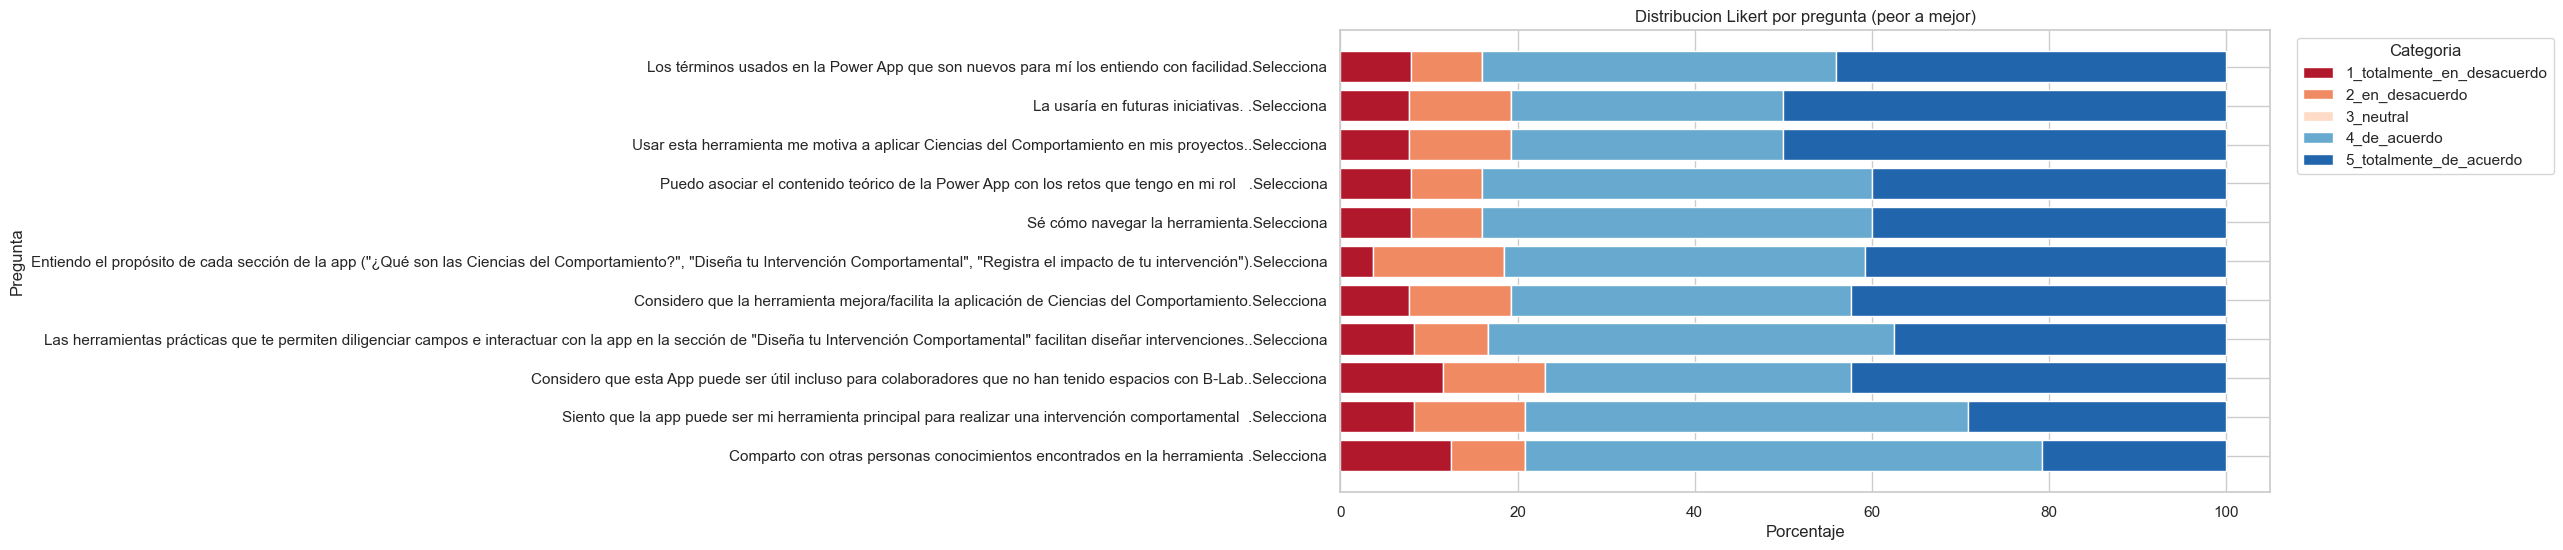

C:\Users\David\AppData\Local\Temp\ipykernel_12036\3037981734.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


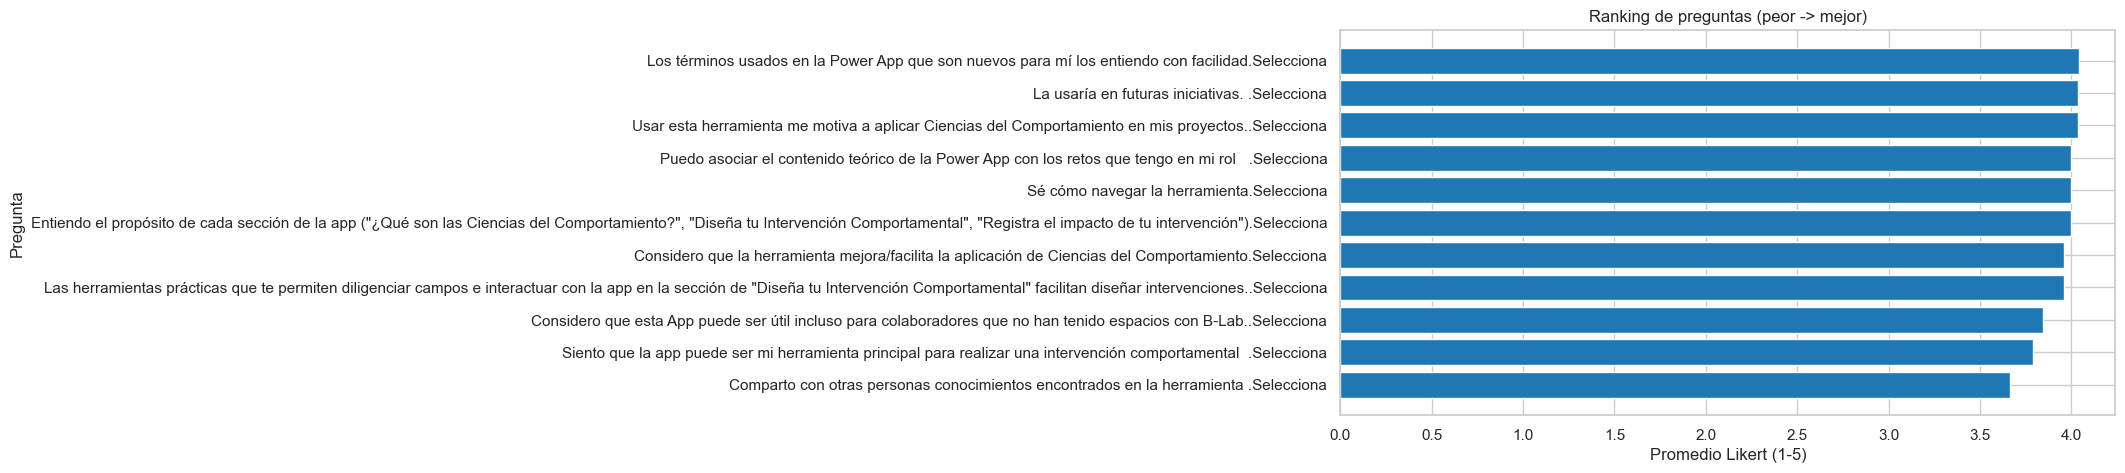

Top 5 peores preguntas:


,pregunta,n_validas,sumatoria,promedio,desviacion,favorabilidad_pct,top_box_pct,desfavorabilidad_pct,neto_favorabilidad_pct
0,Comparto con otras personas conocimientos enco...,24,88.0,3.666667,1.274044,79.166667,20.833333,20.833333,58.333333
1,Siento que la app puede ser mi herramienta pri...,24,91.0,3.791667,1.250362,79.166667,29.166667,20.833333,58.333333
2,Considero que esta App puede ser útil incluso ...,26,100.0,3.846154,1.405484,76.923077,42.307692,23.076923,53.846154
3,Las herramientas prácticas que te permiten dil...,24,95.0,3.958333,1.232853,83.333333,37.500000,16.666667,66.666667
4,Considero que la herramienta mejora/facilita l...,26,103.0,3.961538,1.280024,80.769231,42.307692,19.230769,61.538462


Pregunta peor calificada:
Comparto con otras personas conocimientos encontrados en la herramienta .Selecciona
Resumen global:
{'indice_global': 3.942, 'alfa_cronbach': 0.997, 'n_respuestas': 28, 'n_preguntas_likert': 11}


In [15]:
# Grafico Likert apilado (porcentaje)
freq_plot = freq_df.set_index("pregunta")
freq_pct = freq_plot.div(freq_plot.sum(axis=1), axis=0) * 100

order = metrics_df["pregunta"].tolist()  # peor -> mejor
freq_pct = freq_pct.loc[order]

likert_colors = ["#b2182b", "#ef8a62", "#fddbc7", "#67a9cf", "#2166ac"]
fig, ax = plt.subplots(figsize=(12, max(6, len(order) * 0.5)))
left = np.zeros(len(freq_pct))

for i, col in enumerate(freq_pct.columns):
    ax.barh(freq_pct.index, freq_pct[col], left=left, color=likert_colors[i], label=col)
    left += freq_pct[col].values

ax.set_xlabel("Porcentaje")
ax.set_ylabel("Pregunta")
ax.set_title("Distribucion Likert por pregunta (peor a mejor)")
ax.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Grafico ranking por promedio
fig, ax = plt.subplots(figsize=(10, max(5, len(order) * 0.45)))
ax.barh(metrics_df["pregunta"], metrics_df["promedio"], color="#1f77b4")
ax.set_xlabel("Promedio Likert (1-5)")
ax.set_ylabel("Pregunta")
ax.set_title("Ranking de preguntas (peor -> mejor)")
plt.tight_layout()
plt.show()

print("Top 5 peores preguntas:")
display(metrics_df.head(5))

print("Pregunta peor calificada:")
print(worst_question)

print("Resumen global:")
print({
    "indice_global": round(global_index, 3),
    "alfa_cronbach": None if pd.isna(alpha) else round(alpha, 3),
    "n_respuestas": int(df_raw.shape[0]),
    "n_preguntas_likert": int(len(likert_columns)),
})

## 8. Analisis Pre-Pos (Significancia y Potencia)

Esta seccion te ayuda a definir:

- Cual media pos minima necesitas para detectar mejora estadistica.
- Si tu tamano muestral objetivo (por ejemplo 14) es consistente con alpha y potencia.
- Como correr prueba t pareada y Wilcoxon cuando tengas datos emparejados por persona.

In [18]:
from scipy import stats

# Ajusta estos parametros segun tu estudio
PRE_INDICE_GLOBAL = 3.906
N_PRE = 27
ALPHA = 0.07
POWER_TARGET = 0.80
ONE_SIDED = True  # True si la hipotesis es "pos > pre"

# Escenarios para desviacion de cambios individuales (pos - pre)
SD_DELTA_SCENARIOS = [0.5, 0.6, 0.8, 1.0]


def required_delta_for_significance(n: int, sd_delta: float, alpha: float = 0.05, one_sided: bool = True) -> float:
    """Delta minimo para rechazar H0 con t pareada (aprox umbral de significancia)."""
    tail_alpha = alpha if one_sided else alpha / 2
    t_crit = stats.t.ppf(1 - tail_alpha, df=n - 1)
    return float(t_crit * sd_delta / np.sqrt(n))


def required_delta_for_power(n: int, sd_delta: float, alpha: float = 0.05, power: float = 0.8, one_sided: bool = True) -> float:
    """Delta aproximado para lograr potencia objetivo (aproximacion normal)."""
    tail_alpha = alpha if one_sided else alpha / 2
    z_alpha = stats.norm.ppf(1 - tail_alpha)
    z_beta = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * sd_delta / np.sqrt(n))


rows = []
for sd in SD_DELTA_SCENARIOS:
    delta_sig = required_delta_for_significance(N_PRE, sd, ALPHA, ONE_SIDED)
    delta_pow = required_delta_for_power(N_PRE, sd, ALPHA, POWER_TARGET, ONE_SIDED)
    rows.append({
        "n": N_PRE,
        "alpha": ALPHA,
        "power_objetivo": POWER_TARGET,
        "sd_delta_supuesto": sd,
        "delta_min_significancia": round(delta_sig, 3),
        "delta_min_potencia": round(delta_pow, 3),
        "media_pos_min_significativa": round(PRE_INDICE_GLOBAL + delta_sig, 3),
        "media_pos_min_con_potencia": round(PRE_INDICE_GLOBAL + delta_pow, 3),
    })

thresholds_df = pd.DataFrame(rows)
print("Umbrales sugeridos para declarar mejora en pre-pos")
display(thresholds_df)

# Corroboracion rapida del caso n=14 que mencionaste
N_CHECK = 14
check_rows = []
for sd in SD_DELTA_SCENARIOS:
    d_pow_14 = required_delta_for_power(N_CHECK, sd, ALPHA, POWER_TARGET, ONE_SIDED)
    check_rows.append({
        "n": N_CHECK,
        "sd_delta_supuesto": sd,
        "delta_min_potencia": round(d_pow_14, 3),
        "tamano_efecto_dz_aprox": round(d_pow_14 / sd, 3),
    })

print("\nCorroboracion n=14 (alpha=0.07, potencia=0.8)")
display(pd.DataFrame(check_rows))

Umbrales sugeridos para declarar mejora en pre-pos


,n,alpha,power_objetivo,sd_delta_supuesto,delta_min_significancia,delta_min_potencia,media_pos_min_significativa,media_pos_min_con_potencia
0,27,0.07,0.8,0.5,0.146,0.223,4.052,4.129
1,27,0.07,0.8,0.6,0.176,0.268,4.082,4.174
2,27,0.07,0.8,0.8,0.234,0.357,4.140,4.263
3,27,0.07,0.8,1.0,0.293,0.446,4.199,4.352



Corroboracion n=14 (alpha=0.07, potencia=0.8)


,n,sd_delta_supuesto,delta_min_potencia,tamano_efecto_dz_aprox
0,14,0.5,0.310,0.619
1,14,0.6,0.372,0.619
2,14,0.8,0.495,0.619
3,14,1.0,0.619,0.619


In [19]:
def evaluate_paired_pre_post(pre_scores, pos_scores, alpha=0.07, alternative="greater"):
    """Evalua mejora pre-pos con t pareada, Wilcoxon y tamano de efecto dz."""
    pre = pd.Series(pre_scores, dtype="float").dropna().reset_index(drop=True)
    pos = pd.Series(pos_scores, dtype="float").dropna().reset_index(drop=True)

    if len(pre) != len(pos):
        raise ValueError("pre_scores y pos_scores deben tener el mismo largo (pareados por persona).")
    if len(pre) < 3:
        raise ValueError("Se necesitan al menos 3 pares para evaluar pre-pos.")

    diff = pos - pre
    mean_diff = float(diff.mean())
    sd_diff = float(diff.std(ddof=1))
    n = int(len(diff))

    t_res = stats.ttest_rel(pos, pre, nan_policy="omit")
    t_stat = float(t_res.statistic)
    p_two = float(t_res.pvalue)

    if alternative == "greater":
        p_value = p_two / 2 if t_stat > 0 else 1 - (p_two / 2)
    elif alternative == "less":
        p_value = p_two / 2 if t_stat < 0 else 1 - (p_two / 2)
    else:
        p_value = p_two

    # Wilcoxon en dos colas como respaldo no parametrico
    try:
        w_res = stats.wilcoxon(pos, pre, zero_method="wilcox", alternative="two-sided")
        w_p = float(w_res.pvalue)
    except Exception:
        w_p = np.nan

    dz = mean_diff / sd_diff if sd_diff > 0 else np.nan

    ci = stats.t.interval(
        confidence=0.95,
        df=n - 1,
        loc=mean_diff,
        scale=sd_diff / np.sqrt(n),
    )

    return {
        "n_pares": n,
        "media_pre": float(pre.mean()),
        "media_pos": float(pos.mean()),
        "delta_media_pos_menos_pre": mean_diff,
        "p_value_t_pareada": p_value,
        "p_value_wilcoxon_2s": w_p,
        "dz": dz,
        "ic95_delta": (float(ci[0]), float(ci[1])),
        "significativo_alpha": bool(p_value < alpha),
    }


# Ejemplo de uso (descomenta y reemplaza con tus datos pareados reales):
pre_scores = [3.2, 3.8, 4.1]
pos_scores = [3.9, 4.0, 4.4]
result = evaluate_paired_pre_post(pre_scores, pos_scores, alpha=ALPHA, alternative="greater")
result

{'n_pares': 3,
 'media_pre': 3.6999999999999997,
 'media_pos': 4.1000000000000005,
 'delta_media_pos_menos_pre': 0.4000000000000002,
 'p_value_t_pareada': 0.060058654935939954,
 'p_value_wilcoxon_2s': 0.25,
 'dz': 1.5118578920369117,
 'ic95_delta': (-0.25724106077284176, 1.0572410607728422),
 'significativo_alpha': True}